In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('heart - heart.csv')

# Display dataset
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
# Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Apply Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predictions
y_pred_lr = model_lr.predict(X_test)
# Evaluation
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

Linear Regression Performance:
MAE: 0.3096660894747362
MSE: 0.14759448520056803
R2 Score: 0.4096080106078551


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Create model
model_dt = DecisionTreeClassifier(random_state=42)

# Train model
model_dt.fit(X_train, y_train)

# Predictions
y_pred_dt = model_dt.predict(X_test)
# Evaluation
accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy)
# Detailed Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9853658536585366

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [4]:
# Confusion Matrix
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

Confusion Matrix:

[[102   0]
 [  3 100]]


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')


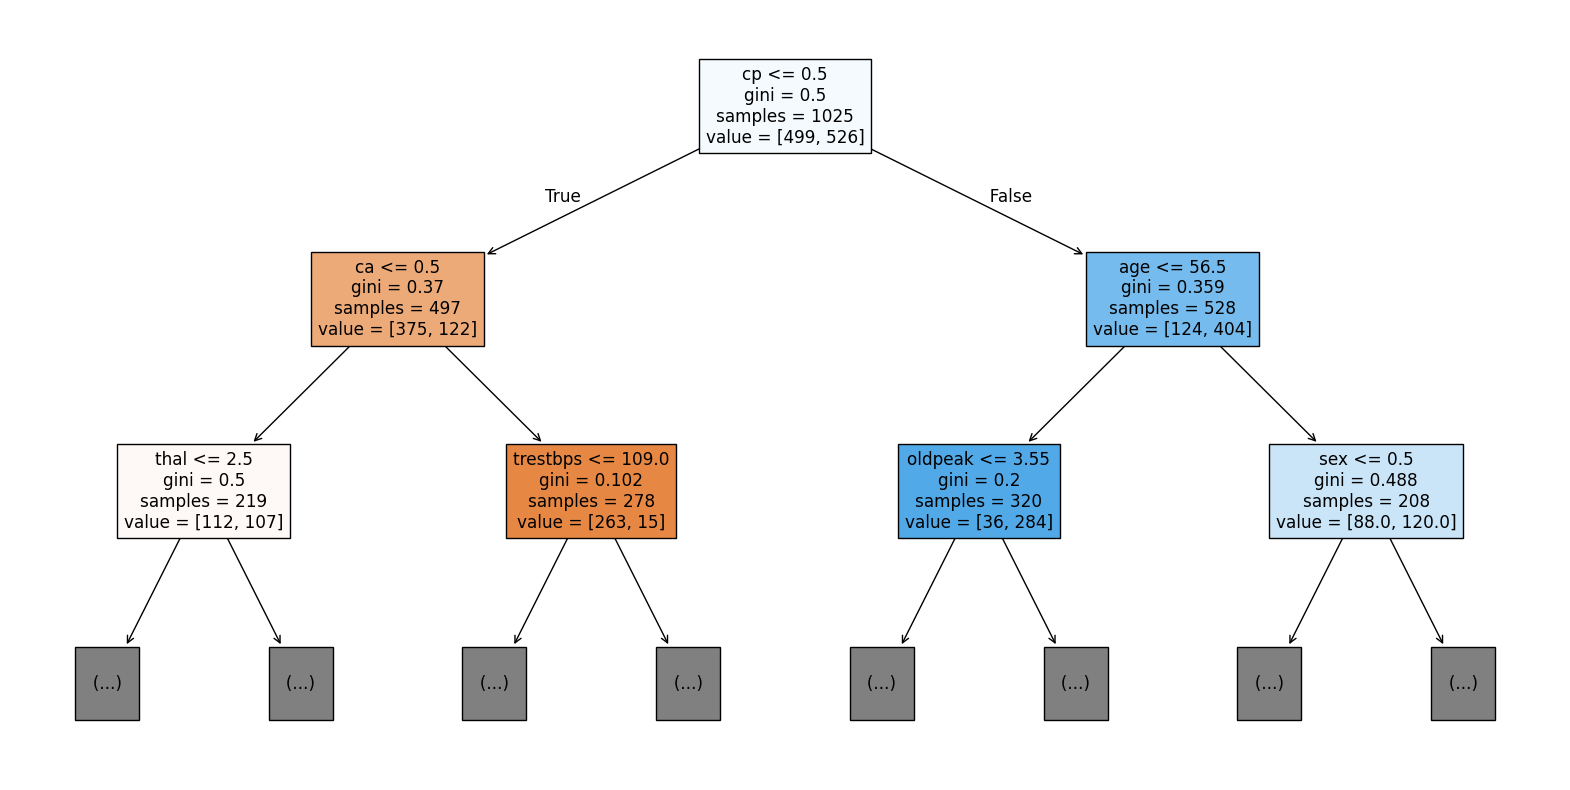

In [9]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('heart - heart.csv')

# Check columns (optional but recommended)
print(df.columns)

# Split data correctly
X = df.drop('target', axis=1)
y = df['target']

# Train model
model_dt = DecisionTreeClassifier()
model_dt.fit(X, y)

# Plot tree (3 levels)
plt.figure(figsize=(20,10))
plot_tree(
    model_dt,
    filled=True,
    feature_names=X.columns,
    max_depth=2
)
plt.show()

In [6]:
# Linear Regression Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Linear Regression Evaluation:\n")

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared (R2 Score):", r2)

Linear Regression Evaluation:

Mean Absolute Error (MAE): 0.3096660894747362
Mean Squared Error (MSE): 0.14759448520056803
R-squared (R2 Score): 0.4096080106078551


In [7]:
# Decision Tree Evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n Decision Tree Evaluation:\n")

# Accuracy
accuracy = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))


 Decision Tree Evaluation:

Accuracy: 0.9853658536585366

Confusion Matrix:

[[102   0]
 [  3 100]]

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



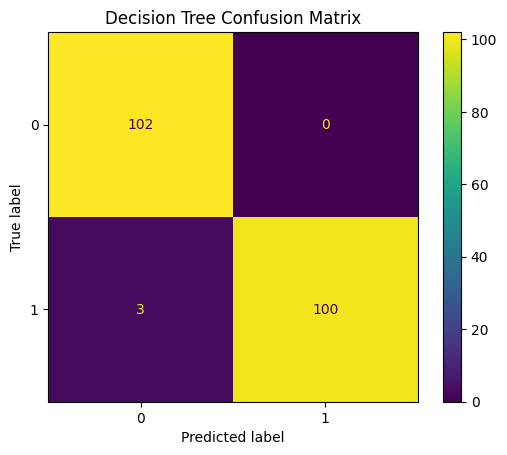

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)

plt.title("Decision Tree Confusion Matrix")
plt.show()

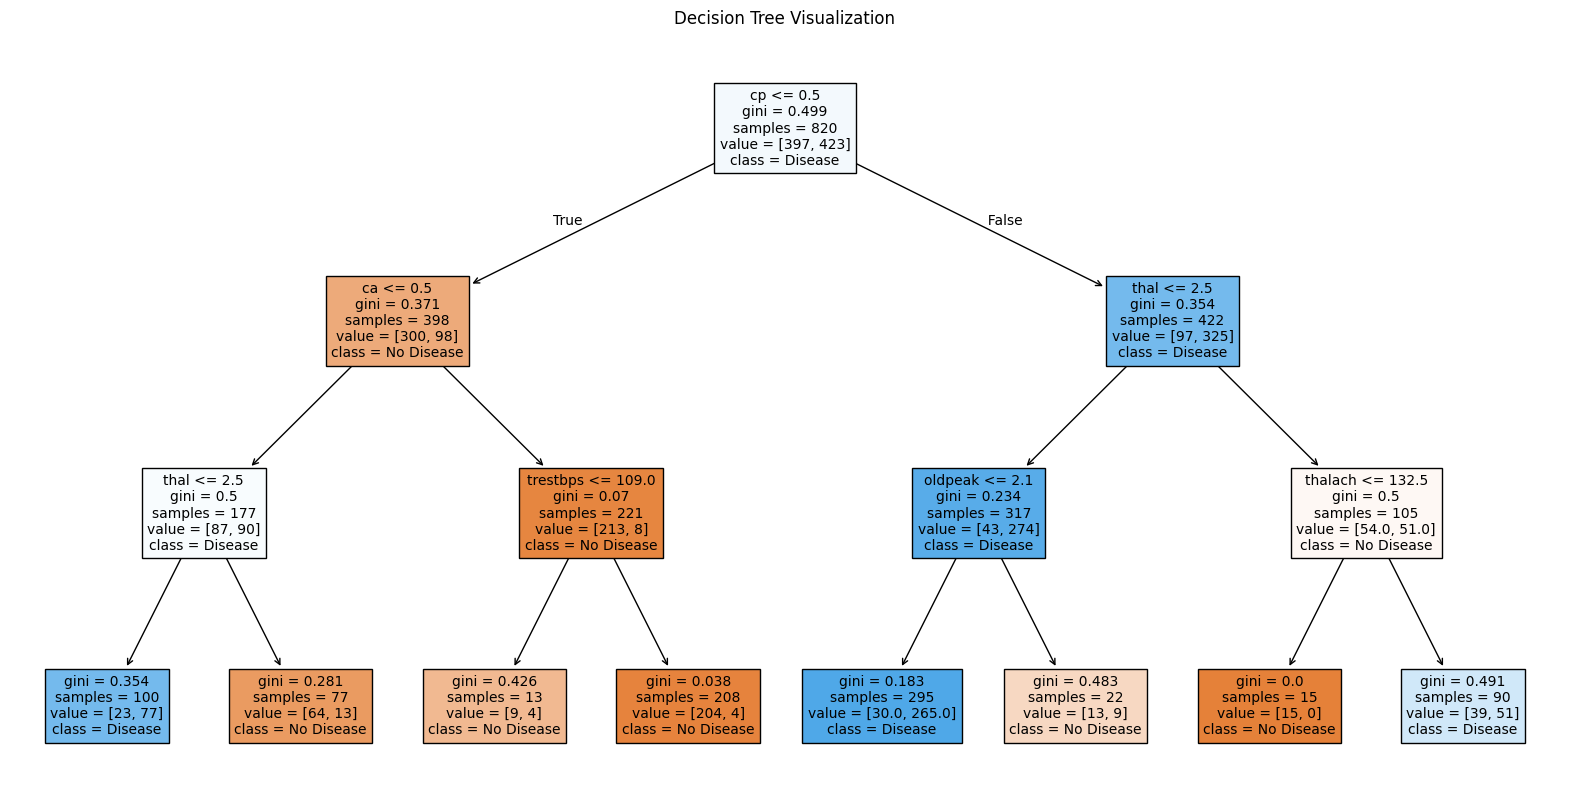

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Train a smaller tree for visualization
model_dt_small = DecisionTreeClassifier(max_depth=3, random_state=42)
model_dt_small.fit(X_train, y_train)

# Plot tree
plt.figure(figsize=(20,10))
plot_tree(
    model_dt_small,
    filled=True,
    feature_names=X.columns,
    class_names=['No Disease', 'Disease'],
    fontsize=10
)

plt.title("Decision Tree Visualization")
plt.show()

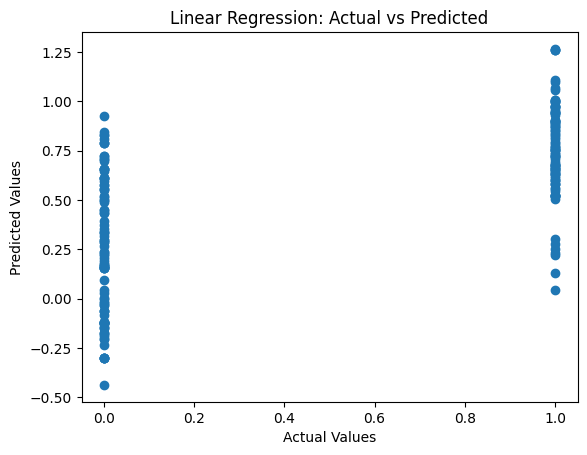

In [10]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

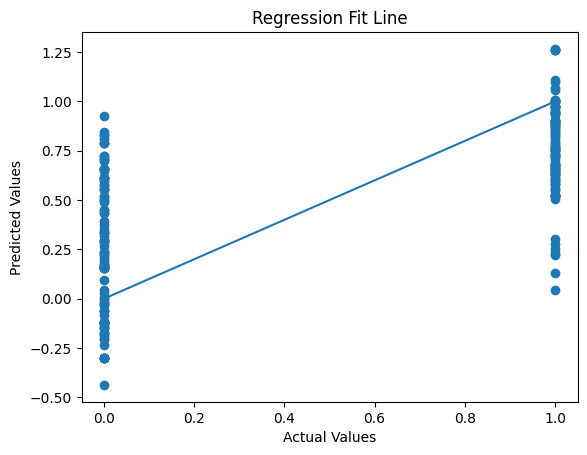

In [11]:
plt.figure()

plt.scatter(y_test, y_pred_lr)

# Perfect prediction line
plt.plot([0,1], [0,1])

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Regression Fit Line")

plt.show()